# Model Development
Discrete-time logistic hazard model for one-quarter-ahead probability of default.
Follows the case-control sampling design with WESML intercept correction.

**Macro variable selection follows the bank standard approach:**
1. Candidate generation — one variable per economic channel
2. Univariate AUC screen — incremental lift over loan-only model
3. Sign and stationarity filter — economic theory constraints
4. Quarterly VIF filter — collinearity at the macro level
5. Final model fit on selected variables

**Flow:** Load → Missing values → Macro variable selection → Train/test split
→ Feature matrix → Fit → Intercept correction → Diagnostics → Save

## 1. Imports

In [1]:
import json
import pickle
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss

## 2. Load Data

In [2]:
# Load loan panel -- macro columns are NOT in the parquet
# They are merged on the fly during variable selection below
LOAN_COLS = ['ID', 'q', 'target', 'LTV', 'DTI', 'FICO', 'Age']

df = pd.read_parquet('full_panel.parquet', columns=LOAN_COLS)
print(f'Rows:  {len(df):,}')
print(f'Loans: {df["ID"].nunique():,}')
print(f'Default rate (sample): {df["target"].mean()*100:.4f}%')
df.head(3)

Rows:  54,199,536
Loans: 2,693,621
Default rate (sample): 2.6614%


,ID,q,target,LTV,DTI,FICO,Age
0,100023274028,2000-01-01,0,61.0,34.0,646.0,1.0
1,100023274028,2000-04-01,0,61.0,34.0,646.0,4.0
2,100023274028,2000-07-01,0,61.0,34.0,646.0,7.0


## 3. Sampling Statistics

In [3]:
# Load macro panel -- kept separate from loan panel to avoid memory issues
macro = pd.read_csv(
    'macro_panel_quarterly.csv',
    index_col=0,
    parse_dates=True
)
macro.index.name = 'q'
print(f'Macro panel: {macro.shape[0]} quarters x {macro.shape[1]} columns')

Macro panel: 427 quarters x 80 columns


In [4]:
with open('sampling_stats.json') as f:
    sampling_stats = json.load(f)

TAU_EFF              = sampling_stats['tau_eff']
INTERCEPT_CORRECTION = sampling_stats['intercept_correction']

print(f'tau_eff              : {TAU_EFF:.6f}')
print(f'Intercept correction : {INTERCEPT_CORRECTION:.6f}')

tau_eff              : 0.098659
Intercept correction : -2.316088


## 4. Missing Value Treatment

In [5]:
print('Missing values per column (loan variables):')
print(df.isnull().sum())
print(f'\nTotal rows: {len(df):,}')

df_model = df.dropna(subset=['LTV', 'DTI', 'FICO', 'Age']).copy()

dropped = df[df[['LTV', 'DTI', 'FICO', 'Age']].isnull().any(axis=1)]
print(f'\nRows after drop: {len(df_model):,}')
print(f'Default rate dropped: {dropped["target"].mean()*100:.4f}%')
print(f'Default rate kept:    {df_model["target"].mean()*100:.4f}%')
del df

Missing values per column (loan variables):
ID              0
q               0
target          0
LTV            20
DTI       1774046
FICO       333050
Age       1220963
dtype: int64

Total rows: 54,199,536

Rows after drop: 50,933,331
Default rate dropped: 1.9987%
Default rate kept:    2.7039%


## 5. Macro Variable Selection

Combinatorial search over a curated universe of canonical macro series
and their standard transforms.

**Why this approach:**
- Canonical series (unemployment, HPI, GDP, rates, credit spread) are
  chosen by economic theory -- every selected variable is interpretable
- All their standard transforms (YoY, QoQ, log, lags) are tested --
  the data picks which transform performs best
- Combinatorial search over ~25-30 variables is fast (seconds to minutes)
  and finds the best 3-variable combination

**Steps:**
1. Define canonical series and generate all transforms
2. ADF stationarity filter (p < 0.11)
3. Univariate AUC + sign screen against loan-only baseline
4. Enumerate C(n, 3) combinations, keep those with low pairwise correlation
5. Evaluate joint AUC for each valid combination
6. Select best combination with correct joint signs

In [7]:
# ── Step 1: Canonical series and transforms ─────────────────────────
#
# Five canonical series covering the primary mortgage default channels.
# Series are chosen by theory; transforms are generated automatically.
# All transforms of all series feed into the combinatorial search.
#
# unemployment_rate  -- income channel: inability to pay
# hpi_cs             -- equity channel: unwillingness to pay (CS = broader coverage)
# real_gdp           -- activity channel: broad economic conditions
# treasury_10y       -- rate channel: long-term borrowing cost and refinancing
# hy_spread          -- credit channel: broad financial stress

from statsmodels.tsa.stattools import adfuller
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

ADF_START   = '2000-01-01'
ADF_PVAL    = 0.11
AUC_THRESH  = 0.001
CORR_THRESH = 0.50
COMBO_SIZE  = 3

CANONICAL_SERIES = [
    'unemployment_rate',
    'hpi_cs',
    'real_gdp',
    'treasury_10y',
    'hy_spread',
]

# Transforms to generate per series
# diff_1 = QoQ change, diff_4 = YoY change
# log_diff_1 = QoQ log growth, log_diff_4 = YoY log growth
# lag_1, lag_2, lag_4 applied to each transform above
TRANSFORMS = ['diff_1', 'diff_4', 'log_diff_4', 'log_diff_1']
LAGS        = [0, 1, 2]

def make_transform(s, t):
    if t == 'diff_1':
        return s.diff(1)
    elif t == 'diff_4':
        return s.diff(4)
    elif t == 'log_diff_4':
        return (np.log(s) - np.log(s.shift(4))) * 100
    elif t == 'log_diff_1':
        return (np.log(s) - np.log(s.shift(1))) * 100
    return None

# Build the universe DataFrame on quarterly macro index
macro_q  = macro.loc[ADF_START:].copy()
universe = {}

for raw in CANONICAL_SERIES:
    # Find the raw level column in macro panel
    if raw not in macro_q.columns:
        print(f'WARNING: {raw} not in macro panel -- skipping')
        continue
    s = macro_q[raw]
    for t in TRANSFORMS:
        ts = make_transform(s, t)
        if ts is None:
            continue
        for lag in LAGS:
            name = f'{raw}_{t}' if lag == 0 else f'{raw}_{t}_lag{lag}'
            universe[name] = ts.shift(lag)

universe_df = pd.DataFrame(universe, index=macro_q.index)

print(f'Canonical series:  {CANONICAL_SERIES}')
print(f'Transforms:        {TRANSFORMS}')
print(f'Lags:              {LAGS}')
print(f'Universe size:     {len(universe_df.columns)} variables')
print()
print('Variables per canonical series:')
for raw in CANONICAL_SERIES:
    vs = [v for v in universe_df.columns if v.startswith(raw)]
    print(f'  {raw:<20}: {len(vs)}  {vs}')

# Lookup: variable name -> canonical raw series
# Used in combination enumeration to enforce the one-series-per-combo rule
VAR_TO_ROOT = {
    v: raw
    for raw in CANONICAL_SERIES
    for v in universe_df.columns
    if v.startswith(raw)
}

Canonical series:  ['unemployment_rate', 'hpi_cs', 'real_gdp', 'treasury_10y', 'hy_spread']
Transforms:        ['diff_1', 'diff_4', 'log_diff_4', 'log_diff_1']
Lags:              [0, 1, 2]
Universe size:     60 variables

Variables per canonical series:
  unemployment_rate   : 12  ['unemployment_rate_diff_1', 'unemployment_rate_diff_1_lag1', 'unemployment_rate_diff_1_lag2', 'unemployment_rate_diff_4', 'unemployment_rate_diff_4_lag1', 'unemployment_rate_diff_4_lag2', 'unemployment_rate_log_diff_4', 'unemployment_rate_log_diff_4_lag1', 'unemployment_rate_log_diff_4_lag2', 'unemployment_rate_log_diff_1', 'unemployment_rate_log_diff_1_lag1', 'unemployment_rate_log_diff_1_lag2']
  hpi_cs              : 12  ['hpi_cs_diff_1', 'hpi_cs_diff_1_lag1', 'hpi_cs_diff_1_lag2', 'hpi_cs_diff_4', 'hpi_cs_diff_4_lag1', 'hpi_cs_diff_4_lag2', 'hpi_cs_log_diff_4', 'hpi_cs_log_diff_4_lag1', 'hpi_cs_log_diff_4_lag2', 'hpi_cs_log_diff_1', 'hpi_cs_log_diff_1_lag1', 'hpi_cs_log_diff_1_lag2']
  real_gdp          

In [8]:
# ── Step 2: ADF stationarity filter ─────────────────────────────────
adf_pass  = []
adf_pvals = {}

for var in universe_df.columns:
    s = universe_df[var].dropna()
    if len(s) < 40:
        continue
    try:
        _, pval, *_ = adfuller(s, autolag='AIC')
        adf_pvals[var] = pval
        if pval < ADF_PVAL:
            adf_pass.append(var)
    except Exception:
        pass

print(f'ADF pass (p < {ADF_PVAL}): {len(adf_pass)} / {len(universe_df.columns)}')
print()
print(f'{"Variable":<50}  {"ADF p":>8}  {"Pass"}')
print('-' * 70)
for raw in CANONICAL_SERIES:
    vs = sorted([v for v in universe_df.columns if v.startswith(raw)],
                key=lambda v: adf_pvals.get(v, 99))
    for v in vs:
        p    = adf_pvals.get(v, None)
        pstr = f'{p:.4f}' if p is not None else 'N/A'
        flag = 'PASS' if v in adf_pass else 'fail'
        print(f'  {v:<50}  {pstr:>8}  {flag}')
    print()

ADF pass (p < 0.11): 33 / 60

Variable                                               ADF p  Pass
----------------------------------------------------------------------
  unemployment_rate_diff_1                              0.0000  PASS
  unemployment_rate_diff_1_lag1                         0.0000  PASS
  unemployment_rate_diff_1_lag2                         0.0000  PASS
  unemployment_rate_log_diff_1                          0.0000  PASS
  unemployment_rate_log_diff_1_lag1                     0.0000  PASS
  unemployment_rate_log_diff_1_lag2                     0.0000  PASS
  unemployment_rate_diff_4                              0.0119  PASS
  unemployment_rate_log_diff_4_lag1                     0.0122  PASS
  unemployment_rate_diff_4_lag1                         0.0123  PASS
  unemployment_rate_log_diff_4                          0.0125  PASS
  unemployment_rate_diff_4_lag2                         0.0132  PASS
  unemployment_rate_log_diff_4_lag2                     0.0136  PASS

  h

In [9]:
# ── Step 3: Univariate AUC + sign screen ────────────────────────────
LOAN_FEATURES = ['LTV', 'DTI', 'FICO']
AGE_BINS      = [0, 6, 12, 24, 60, 120, 9999]
AGE_LABELS    = ['0-6', '6-12', '12-24', '24-60', '60-120', '120+']

# Expected sign per canonical series
# Transforms (diff, log) preserve direction; lags preserve direction
EXPECTED_SIGN = {
    'unemployment_rate': +1,   # rising unemployment -> more defaults
    'hpi_cs':            -1,   # rising prices -> fewer defaults
    'real_gdp':          -1,   # stronger economy -> fewer defaults
    'treasury_10y':      +1,   # rising rates -> tighter credit -> more defaults
    'hy_spread':         +1,   # wider spread -> market stress -> more defaults
}

def get_expected_sign(var):
    for raw, sign in EXPECTED_SIGN.items():
        if var.startswith(raw):
            return sign
    return 0

def build_X_base(d):
    d = d.copy()
    d['age_bucket'] = pd.cut(d['Age'], bins=AGE_BINS, labels=AGE_LABELS,
                             right=True, include_lowest=True)
    dummies = pd.get_dummies(d['age_bucket'], drop_first=True, dtype=int)
    dummies.columns = [f'age_{c}' for c in dummies.columns]
    return sm.add_constant(
        pd.concat([d[LOAN_FEATURES], dummies], axis=1),
        has_constant='add'
    )

# Sample -- merge all ADF-passing vars at once
adf_df  = universe_df[adf_pass].reset_index().rename(columns={'index': 'q'})
samp    = df_model.sample(n=min(2_000_000, len(df_model)), random_state=42)
samp    = samp.merge(adf_df, on='q', how='left')
samp_c  = samp.dropna(subset=LOAN_FEATURES + ['Age'])
X_base  = build_X_base(samp_c)
y_samp  = samp_c['target'].astype(int)

base_fit = sm.Logit(y_samp, X_base).fit(disp=False, maxiter=100, method='bfgs')
base_auc = roc_auc_score(y_samp, base_fit.predict(X_base))
print(f'Baseline AUC (loan-only): {base_auc:.4f}')
print(f'Screening {len(adf_pass)} ADF-passing variables...')

screen       = {}
sign_ok_vars = []

for var in adf_pass:
    if var not in samp_c.columns:
        continue
    valid = samp_c[var].notna()
    if valid.sum() < 100_000:
        continue
    X_u      = X_base.loc[valid].copy()
    X_u[var] = samp_c.loc[valid, var].values
    try:
        fit  = sm.Logit(y_samp[valid], X_u).fit(disp=False, maxiter=50, method='bfgs')
        lift = roc_auc_score(y_samp[valid], fit.predict(X_u)) - base_auc
        coef = fit.params[var]
    except Exception:
        continue
    exp     = get_expected_sign(var)
    sign_ok = (exp == 0) or (np.sign(coef) == exp)
    screen[var] = {'lift': lift, 'coef': coef, 'sign_ok': sign_ok}
    if sign_ok and lift >= AUC_THRESH:
        sign_ok_vars.append(var)

print(f'\nSign-correct and lift >= {AUC_THRESH}: {len(sign_ok_vars)}')
print(f'\n{"Variable":<50}  {"Lift":>9}  {"Coef":>8}')
print('-' * 72)
for raw in CANONICAL_SERIES:
    vs = sorted(
        [v for v in sign_ok_vars if v.startswith(raw)],
        key=lambda v: screen[v]['lift'], reverse=True
    )
    for v in vs:
        print(f'  {v:<50}  {screen[v]["lift"]:+9.5f}  {screen[v]["coef"]:+8.4f}')
    if vs:
        print()

Baseline AUC (loan-only): 0.6940
Screening 33 ADF-passing variables...

Sign-correct and lift >= 0.001: 16

Variable                                                 Lift      Coef
------------------------------------------------------------------------
  unemployment_rate_log_diff_4_lag2                    +0.01470   +0.0131
  unemployment_rate_log_diff_4_lag1                    +0.01336   +0.0124
  unemployment_rate_diff_4_lag1                        +0.01207   +0.1846
  unemployment_rate_diff_4_lag2                        +0.01195   +0.1761
  unemployment_rate_log_diff_4                         +0.01111   +0.0126
  unemployment_rate_diff_4                             +0.01065   +0.1736
  unemployment_rate_log_diff_1_lag2                    +0.00411   +0.0205
  unemployment_rate_log_diff_1_lag1                    +0.00338   +0.0200
  unemployment_rate_log_diff_1                         +0.00244   +0.0199
  unemployment_rate_diff_1_lag2                        +0.00176   +0.2586

  hpi_

In [10]:
# ── Step 4: Pairwise correlation matrix ──────────────────────────────
corr_df     = universe_df[sign_ok_vars].dropna(how='all')
corr_matrix = corr_df.corr().abs()

corr_lookup = {
    (v1, v2): float(corr_matrix.loc[v1, v2])
    for v1 in sign_ok_vars for v2 in sign_ok_vars
    if v1 < v2
    and v1 in corr_matrix.index and v2 in corr_matrix.index
}
# symmetric
corr_lookup.update({(v2,v1): r for (v1,v2), r in corr_lookup.items()})

def max_pairwise_corr(combo):
    combo = list(combo)
    return max(
        corr_lookup.get((combo[i], combo[j]), 0.0)
        for i in range(len(combo))
        for j in range(i+1, len(combo))
    )

print(f'Correlation matrix: {len(sign_ok_vars)} x {len(sign_ok_vars)}')
print(f'\nTop correlated pairs (|r| > {CORR_THRESH}):')
high = sorted(
    [(v1, v2, r) for (v1,v2), r in corr_lookup.items() if v1 < v2 and r > CORR_THRESH],
    key=lambda x: -x[2]
)[:12]
for v1, v2, r in high:
    print(f'  r={r:.3f}  {v1}  <->  {v2}')

Correlation matrix: 16 x 16

Top correlated pairs (|r| > 0.5):
  r=0.983  unemployment_rate_diff_1_lag2  <->  unemployment_rate_log_diff_1_lag2
  r=0.981  unemployment_rate_diff_4_lag2  <->  unemployment_rate_log_diff_4_lag2
  r=0.981  unemployment_rate_diff_4_lag1  <->  unemployment_rate_log_diff_4_lag1
  r=0.981  unemployment_rate_diff_4  <->  unemployment_rate_log_diff_4
  r=0.909  real_gdp_diff_1_lag2  <->  unemployment_rate_diff_1_lag2
  r=0.877  real_gdp_log_diff_4_lag2  <->  unemployment_rate_diff_4_lag2
  r=0.877  real_gdp_log_diff_4_lag1  <->  unemployment_rate_diff_4_lag1
  r=0.877  real_gdp_log_diff_4  <->  unemployment_rate_diff_4
  r=0.871  real_gdp_diff_1_lag2  <->  unemployment_rate_log_diff_1_lag2
  r=0.865  real_gdp_log_diff_1_lag1  <->  unemployment_rate_log_diff_1_lag1
  r=0.825  real_gdp_log_diff_4_lag2  <->  unemployment_rate_log_diff_4_lag2
  r=0.825  real_gdp_log_diff_4_lag1  <->  unemployment_rate_log_diff_4_lag1


In [11]:
# ── Step 5: Enumerate valid combinations ─────────────────────────────
# Hard constraints per combination:
#   1. All pairwise correlations < CORR_THRESH
#   2. No two variables from the same canonical raw series
#      (e.g. cannot have both unemployment_rate_diff_4 and
#       unemployment_rate_log_diff_1 in the same combination --
#       they measure the same underlying thing)

def all_different_roots(combo):
    roots = [VAR_TO_ROOT.get(v) for v in combo]
    return len(roots) == len(set(roots))

n     = len(sign_ok_vars)
total = n*(n-1)*(n-2)//6
print(f'C({n}, {COMBO_SIZE}) = {total:,} total combinations')

valid_combos = [
    combo for combo in combinations(sign_ok_vars, COMBO_SIZE)
    if all_different_roots(combo)
    and max_pairwise_corr(combo) < CORR_THRESH
]
print(f'After same-root filter:      '
      f'{sum(1 for c in combinations(sign_ok_vars, COMBO_SIZE) if all_different_roots(c)):,}')
print(f'After correlation filter:    {len(valid_combos):,}')

C(16, 3) = 560 total combinations
After same-root filter:      50
After correlation filter:    32


In [12]:
# ── Step 6: AUC evaluation ───────────────────────────────────────────
print(f'Evaluating {len(valid_combos):,} combinations...')

eval_results = []
for combo in valid_combos:
    combo  = list(combo)
    valid  = samp_c[combo].notna().all(axis=1)
    if valid.sum() < 500_000:
        continue
    X_c = X_base.loc[valid].copy()
    for v in combo:
        X_c[v] = samp_c.loc[valid, v].values
    y_c = y_samp[valid]
    try:
        fit  = sm.Logit(y_c, X_c).fit(disp=False, maxiter=50, method='bfgs')
        auc  = roc_auc_score(y_c, fit.predict(X_c))
        lift = auc - base_auc
        # All signs must be correct in the joint model
        joint_ok = all(
            (get_expected_sign(v) == 0) or
            (np.sign(fit.params[v]) == get_expected_sign(v))
            for v in combo
        )
        eval_results.append({
            'combo':    tuple(combo),
            'auc':      round(auc,  5),
            'lift':     round(lift, 5),
            'joint_ok': joint_ok,
        })
    except Exception:
        pass

eval_df       = pd.DataFrame(eval_results)
valid_results = eval_df[
    eval_df['joint_ok'] & (eval_df['lift'] >= AUC_THRESH)
].sort_values('lift', ascending=False)

print(f'Evaluated: {len(eval_df)}  |  valid (signs+lift): {len(valid_results)}')
print(f'\nTop 10 combinations:')
print(f'{"Rank":<5}  {"Lift":>8}  {"AUC":>7}  Variables')
print('-' * 105)
for rank, (_, row) in enumerate(valid_results.head(10).iterrows(), 1):
    print(f'{rank:<5}  {row["lift"]:8.5f}  {row["auc"]:7.4f}  {str(row["combo"])}')

Evaluating 32 combinations...
Evaluated: 32  |  valid (signs+lift): 22

Top 10 combinations:
Rank       Lift      AUC  Variables
---------------------------------------------------------------------------------------------------------
1       0.01750   0.7115  ('unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4')
2       0.01686   0.7108  ('unemployment_rate_log_diff_1', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4_lag2')
3       0.01569   0.7097  ('unemployment_rate_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4')
4       0.01509   0.7091  ('unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_diff_1_lag2')
5       0.01478   0.7088  ('unemployment_rate_log_diff_1', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4_lag1')
6       0.01464   0.7086  ('unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4_lag1')
7       0.01442   0.7084  ('unemployment_rate_diff_4', 'hpi_cs_log_diff_1_lag2', 'rea

In [13]:
# ── Step 7: Select best combination ──────────────────────────────────
if valid_results.empty:
    raise ValueError('No valid combination. Try relaxing ADF_PVAL or CORR_THRESH.')

best          = valid_results.iloc[0]
MACRO_FEATURES = list(best['combo'])

print('=== SELECTED MACRO VARIABLES ===')
print(f'AUC lift: {best["lift"]:+.5f}  |  Combined AUC: {best["auc"]:.4f}')
print()
for v in MACRO_FEATURES:
    raw  = next(r for r in CANONICAL_SERIES if v.startswith(r))
    p    = adf_pvals.get(v, 'N/A')
    pstr = f'{p:.4f}' if isinstance(p, float) else p
    lift = screen.get(v, {}).get('lift', 0)
    coef = screen.get(v, {}).get('coef', 0)
    print(f'  {v:<50}  [{raw}]  ADF_p={pstr}  lift={lift:+.5f}  coef={coef:+.4f}')

print(f'\nSearch summary:')
print(f'  Universe:           {len(universe_df.columns)}')
print(f'  ADF pass:           {len(adf_pass)}')
print(f'  Sign+lift pass:     {len(sign_ok_vars)}')
print(f'  Valid combos:       {len(valid_combos)}')
print(f'  Evaluated:          {len(eval_df)}')
print(f'  Good joint signs:   {len(valid_results)}')

=== SELECTED MACRO VARIABLES ===
AUC lift: +0.01750  |  Combined AUC: 0.7115

  unemployment_rate_log_diff_4_lag2                   [unemployment_rate]  ADF_p=0.0136  lift=+0.01470  coef=+0.0131
  hpi_cs_log_diff_1_lag2                              [hpi_cs]  ADF_p=0.0338  lift=+0.00355  coef=-0.0840
  real_gdp_log_diff_4                                 [real_gdp]  ADF_p=0.0110  lift=+0.01479  coef=-0.1302

Search summary:
  Universe:           60
  ADF pass:           33
  Sign+lift pass:     16
  Valid combos:       32
  Evaluated:          32
  Good joint signs:   22


## 6. Train / Test Split

In [15]:
CUTOFF = pd.Timestamp('2015-01-01')

# Merge only the selected macro features onto the full loan panel
# Safe memory: ~54M rows x len(MACRO_FEATURES) columns
# For 3-5 features this is ~2-4GB which should be manageable
# If memory is still tight, process in chunks (see note below)
macro_selected = universe_df[MACRO_FEATURES].reset_index().rename(
    columns={'index': 'q'}
)
df_fit = df_model.merge(macro_selected, on='q', how='left')
df_fit = df_fit.dropna(subset=['LTV', 'DTI', 'FICO', 'Age'] + MACRO_FEATURES).copy()

train = df_fit[df_fit['q'] <  CUTOFF].copy()
test  = df_fit[df_fit['q'] >= CUTOFF].copy()

print(f'Train: {len(train):>12,} rows  |  {train["target"].sum():,} defaults  '
      f'|  {train["target"].mean()*100:.4f}%')
print(f'Test:  {len(test):>12,} rows  |  {test["target"].sum():,} defaults  '
      f'|  {test["target"].mean()*100:.4f}%')
print(f'\nTrain period: {train["q"].min().date()} to {train["q"].max().date()}')
print(f'Test period:  {test["q"].min().date()} to {test["q"].max().date()}')

# Free the merged full panel -- not needed after split
del df_fit

Train:   44,102,585 rows  |  1,196,446 defaults  |  2.7129%
Test:     6,316,516 rows  |  170,312 defaults  |  2.6963%

Train period: 2001-07-01 to 2014-10-01
Test period:  2015-01-01 to 2025-04-01


## 7. Feature Matrix
Loan age enters as categorical buckets to capture the non-monotonic hazard profile.
All other variables enter linearly. Macro variables are the selected set above.

In [16]:
def build_features(d):
    d = d.copy()
    d['age_bucket'] = pd.cut(d['Age'], bins=AGE_BINS, labels=AGE_LABELS,
                             right=True, include_lowest=True)
    dummies = pd.get_dummies(d['age_bucket'], drop_first=True, dtype=int)
    dummies.columns = [f'age_{c}' for c in dummies.columns]
    X = pd.concat([d[LOAN_FEATURES + MACRO_FEATURES], dummies], axis=1)
    X = sm.add_constant(X, has_constant='add')
    y      = d['target'].astype(int)
    groups = d['ID']
    return X, y, groups


X_train, y_train, groups_train = build_features(train)
X_test,  y_test,  groups_test  = build_features(test)

print(f'Train shape: {X_train.shape}')
print(f'Test shape:  {X_test.shape}')
print(f'Features: {X_train.columns.tolist()}')

Train shape: (44102585, 12)
Test shape:  (6316516, 12)
Features: ['const', 'LTV', 'DTI', 'FICO', 'unemployment_rate_log_diff_4_lag2', 'hpi_cs_log_diff_1_lag2', 'real_gdp_log_diff_4', 'age_6-12', 'age_12-24', 'age_24-60', 'age_60-120', 'age_120+']


## 8. Final VIF Check on Full Feature Matrix

In [19]:
# Check at quarterly level -- the right level for macro VIF
def quarterly_vif(vars_list):
    X = universe_df[MACRO_FEATURES].dropna()
    return pd.Series(
        {v: variance_inflation_factor(X.values, i)
         for i, v in enumerate(X.columns)}
    )
print('Quarterly VIF (final selected macro variables):')
vifs_final = quarterly_vif(MACRO_FEATURES)
print(vifs_final.sort_values(ascending=False).round(3).to_string())
if (vifs_final > 10).any():
    print('WARNING: VIF > 10 detected. Revisit selection.')
else:
    print('All VIF < 10.')

Quarterly VIF (final selected macro variables):
hpi_cs_log_diff_1_lag2               1.544
real_gdp_log_diff_4                  1.519
unemployment_rate_log_diff_4_lag2    1.040
All VIF < 10.


## 9. Model Fitting

In [20]:
print('Fitting logistic regression with clustered standard errors...')
print('(This may take several minutes on 50M+ rows)\n')

logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit(
    cov_type='cluster',
    cov_kwds={'groups': groups_train},
    disp=False,
    maxiter=100,
)
print(result.summary())

Fitting logistic regression with clustered standard errors...
(This may take several minutes on 50M+ rows)

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:             44102585
Model:                          Logit   Df Residuals:                 44102573
Method:                           MLE   Df Model:                           11
Date:                Tue, 28 Apr 2026   Pseudo R-squ.:                 0.06519
Time:                        16:19:50   Log-Likelihood:            -5.1376e+06
converged:                       True   LL-Null:                   -5.4958e+06
Covariance Type:              cluster   LLR p-value:                     0.000
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -1.7607      0.015 

## 10. Coefficient Review

In [31]:
coef_df = pd.DataFrame({
    'coef':    result.params,
    'se':      result.bse,
    'z':       result.tvalues,
    'p_value': result.pvalues,
}).round(6)

# Use get_expected_sign from variable selection -- handles all variable
# names by raw series prefix, no hardcoded transform names needed
coef_df['expected_sign'] = coef_df.index.map(get_expected_sign)

# Loan variable signs not covered by get_expected_sign -- add manually
LOAN_SIGNS = {'LTV': +1, 'DTI': +1, 'FICO': -1}
for feat, sign in LOAN_SIGNS.items():
    if feat in coef_df.index:
        coef_df.loc[feat, 'expected_sign'] = sign

coef_df['sign_ok'] = coef_df.apply(
    lambda r: True if (r['expected_sign'] == 0 or pd.isna(r['expected_sign']))
              else np.sign(r['coef']) == r['expected_sign'],
    axis=1
)

# Age dummies and intercept: no sign constraint
age_vars = [c for c in coef_df.index if c.startswith('age_')]
coef_df.loc['const', 'sign_ok'] = True
for v in age_vars:
    coef_df.loc[v, 'sign_ok'] = True

print('Coefficient table:')
print(coef_df[['coef', 'se', 'z', 'p_value', 'sign_ok']].to_string())
print(f'\nPseudo R2: {result.prsquared:.4f}')
print(f'Converged: {result.mle_retvals["converged"]}')

bad = coef_df[
    ~coef_df['sign_ok'] &
    coef_df['expected_sign'].notna() &
    (coef_df['expected_sign'] != 0) &
    ~coef_df.index.isin(age_vars + ['const'])
]
if len(bad):
    print(f'\nWRONG SIGNS: {bad.index.tolist()}')
else:
    print('\nAll expected signs correct.')

Coefficient table:
                                       coef        se           z  p_value  sign_ok
const                             -1.760730  0.014600 -120.602048      0.0     True
LTV                                0.016621  0.000067  246.706662      0.0     True
DTI                                0.016894  0.000076  221.547643      0.0     True
FICO                              -0.007175  0.000017 -421.850340      0.0     True
unemployment_rate_log_diff_4_lag2  0.012544  0.000059  212.883011      0.0     True
hpi_cs_log_diff_1_lag2            -0.018319  0.000490  -37.397420      0.0     True
real_gdp_log_diff_4               -0.030595  0.000651  -46.962755      0.0     True
age_6-12                           0.661514  0.006213  106.479132      0.0     True
age_12-24                          1.148918  0.005428  211.670122      0.0     True
age_24-60                          1.462147  0.005166  283.052560      0.0     True
age_60-120                         1.555352  0.005325  29

## 11. Intercept Correction

In [22]:
raw_int       = result.params['const']
corrected_int = raw_int + INTERCEPT_CORRECTION

print(f'Raw intercept:      {raw_int:.6f}')
print(f'Correction (log tau): {INTERCEPT_CORRECTION:.6f}')
print(f'Corrected intercept: {corrected_int:.6f}')


def predict_pd(X, result, intercept_correction):
    log_odds = result.predict(X, which='linear') + intercept_correction
    return 1 / (1 + np.exp(-log_odds))

Raw intercept:      -1.760730
Correction (log tau): -2.316088
Corrected intercept: -4.076818


## 12. In-Sample Diagnostics

In [23]:
BATCH = 500_000
pred_train = np.zeros(len(X_train))
for start in range(0, len(X_train), BATCH):
    end = min(start + BATCH, len(X_train))
    pred_train[start:end] = predict_pd(
        X_train.iloc[start:end], result, INTERCEPT_CORRECTION
    )

auc_train   = roc_auc_score(y_train, pred_train)
brier_train = brier_score_loss(y_train, pred_train)
print(f'Train AUC:       {auc_train:.4f}')
print(f'Train Brier:     {brier_train:.6f}')
print(f'Train mean PD:   {pred_train.mean()*100:.4f}%  (population level)')

Train AUC:       0.7215
Train Brier:     0.026892
Train mean PD:   0.2795%  (population level)


## 13. Out-of-Time Validation

In [24]:
pred_test = np.zeros(len(X_test))
for start in range(0, len(X_test), BATCH):
    end = min(start + BATCH, len(X_test))
    pred_test[start:end] = predict_pd(
        X_test.iloc[start:end], result, INTERCEPT_CORRECTION
    )

auc_test   = roc_auc_score(y_test, pred_test)
brier_test = brier_score_loss(y_test, pred_test)
print(f'Test AUC:        {auc_test:.4f}')
print(f'Test Brier:      {brier_test:.6f}')
print(f'Test mean PD:    {pred_test.mean()*100:.4f}%')

Test AUC:        0.6546
Test Brier:      0.026783
Test mean PD:    0.2608%


### 13.1 ROC Curve

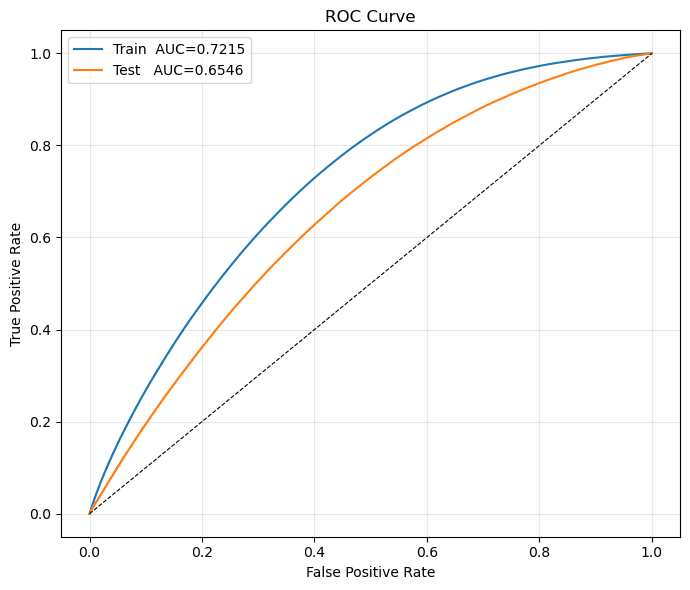

In [25]:
fpr_tr, tpr_tr, _ = roc_curve(y_train, pred_train)
fpr_te, tpr_te, _ = roc_curve(y_test,  pred_test)

plt.figure(figsize=(7, 6))
plt.plot(fpr_tr, tpr_tr, label=f'Train  AUC={auc_train:.4f}', linewidth=1.5)
plt.plot(fpr_te, tpr_te, label=f'Test   AUC={auc_test:.4f}',  linewidth=1.5)
plt.plot([0,1],[0,1], 'k--', linewidth=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.metrics import average_precision_score

prauc_train = average_precision_score(y_train, pred_train)
prauc_test  = average_precision_score(y_test,  pred_test)

print(f'Train PR-AUC:  {prauc_train:.4f}')
print(f'Test  PR-AUC:  {prauc_test:.4f}')
print(f'Train Gini:    {2*auc_train - 1:.4f}')
print(f'Test  Gini:    {2*auc_test  - 1:.4f}')

Train PR-AUC:  0.0597
Test  PR-AUC:  0.0440
Train Gini:    0.4430
Test  Gini:    0.3092


### 13.2 Calibration Plot

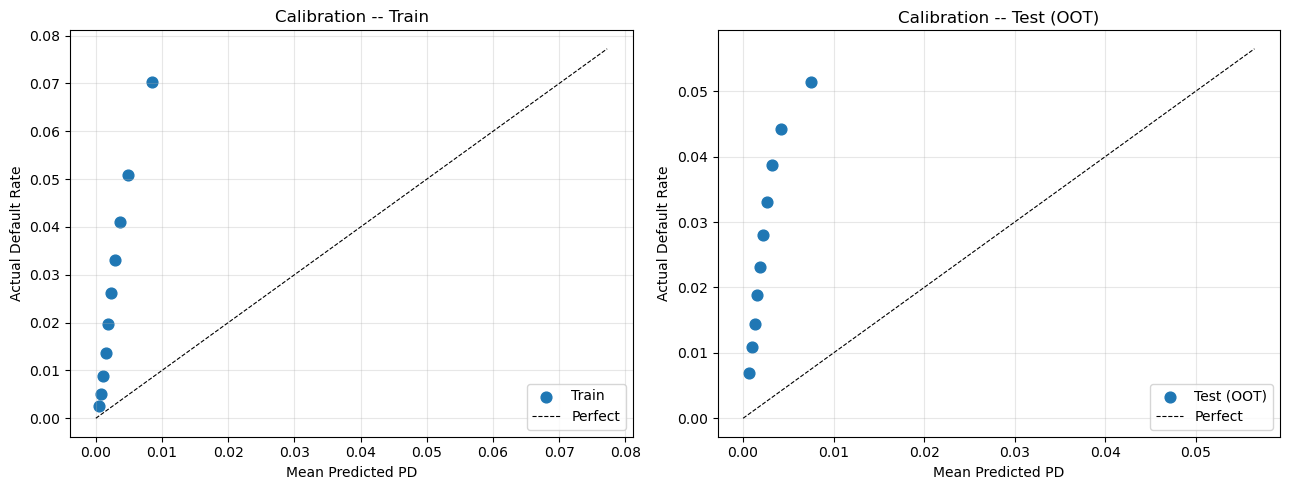

In [26]:
def calibration_plot(y_true, y_pred, label, ax, n_bins=10):
    temp = pd.DataFrame({'actual': y_true, 'pred': y_pred})
    temp['decile'] = pd.qcut(y_pred, q=n_bins, labels=False, duplicates='drop')
    cal = (temp.groupby('decile')
               .agg(mean_pred=('pred', 'mean'), actual_rate=('actual', 'mean'))
               .reset_index())
    ax.scatter(cal['mean_pred'], cal['actual_rate'], label=label, s=60)
    return cal


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, y, p, label in [
    (axes[0], y_train.values, pred_train, 'Train'),
    (axes[1], y_test.values,  pred_test,  'Test (OOT)'),
]:
    cal = calibration_plot(y, p, label, ax)
    mx  = max(cal['mean_pred'].max(), cal['actual_rate'].max()) * 1.1
    ax.plot([0, mx], [0, mx], 'k--', linewidth=0.8, label='Perfect')
    ax.set_xlabel('Mean Predicted PD')
    ax.set_ylabel('Actual Default Rate')
    ax.set_title(f'Calibration -- {label}')
    ax.legend()
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 13.3 KS Statistic

In [27]:
def ks_stat(y_true, y_pred):
    d   = np.sort(y_pred[y_true == 1])
    nd  = np.sort(y_pred[y_true == 0])
    thr = np.sort(np.unique(y_pred))
    cdf_d  = np.searchsorted(d,  thr, side='right') / len(d)
    cdf_nd = np.searchsorted(nd, thr, side='right') / len(nd)
    return np.max(np.abs(cdf_d - cdf_nd))


ks_train = ks_stat(y_train.values, pred_train)
ks_test  = ks_stat(y_test.values,  pred_test)
print(f'KS -- Train: {ks_train:.4f}')
print(f'KS -- Test:  {ks_test:.4f}')

KS -- Train: 0.3301
KS -- Test:  0.2323


## 14. Save

In [33]:
model_meta = {
    'intercept_correction': INTERCEPT_CORRECTION,
    'tau_eff':              TAU_EFF,
    'loan_features':        LOAN_FEATURES,
    'macro_features':       MACRO_FEATURES,
    'macro_selection': {
        'universe_size':       len(universe),
        'adf_pass':            adf_pass,
        'sign_lift_pass':      sign_ok_vars,
        'valid_combos':        len(valid_combos),
        'evaluated':           len(eval_df),
        'final_selected':      MACRO_FEATURES,
    },
    'age_bins':    AGE_BINS,
    'age_labels':  AGE_LABELS,
    'train_cutoff': str(CUTOFF.date()),
    'metrics': {
        'train_auc':    round(auc_train,   4),
        'test_auc':     round(auc_test,    4),
        'train_brier':  round(brier_train, 6),
        'test_brier':   round(brier_test,  6),
        'train_ks':     round(ks_train,    4),
        'test_ks':      round(ks_test,     4),
        'train_prauc': round(prauc_train, 4),
        'test_prauc':  round(prauc_test,  4),
        'train_gini':  round(2*auc_train - 1, 4),
        'test_gini':   round(2*auc_test  - 1, 4),
    }
}